# Heart Disease Classification – MLOps Pipeline
**Nama:** Josa Pratama  
**Username Dicoding:** josa_pratama  

---

## Deskripsi Proyek

Notebook ini membangun sebuah machine learning pipeline end-to-end menggunakan **TensorFlow Extended (TFX)** untuk mengklasifikasikan apakah seorang pasien menderita penyakit jantung berdasarkan data klinis. Pipeline dijalankan menggunakan **Apache Beam** sebagai Pipeline Orchestrator.

Pipeline ini mencakup seluruh komponen:
1. **ExampleGen** – Ingesti dan split data
2. **StatisticsGen** – Statistik deskriptif
3. **SchemaGen** – Pembuatan schema otomatis
4. **ExampleValidator** – Validasi data
5. **Transform** – Preprocessing & feature engineering
6. **Tuner** – Hyperparameter tuning otomatis
7. **Trainer** – Training model
8. **Resolver** – Resolusi model baseline
9. **Evaluator** – Evaluasi model
10. **Pusher** – Deployment model

## 1. Dataset

Dataset yang digunakan adalah **Heart Disease UCI Dataset** dari UCI Machine Learning Repository.

### Informasi Dataset

| Atribut | Nilai |
|---------|-------|
| Jumlah sampel | 199 |
| Jumlah fitur | 13 |
| Target | Binary (0 = tidak sakit, 1 = sakit jantung) |
| Missing values | Tidak ada |

### Deskripsi Fitur

| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| age | Usia pasien (tahun) | Numerik |
| sex | Jenis kelamin (1=pria, 0=wanita) | Kategorikal |
| cp | Tipe nyeri dada (0-3) | Kategorikal |
| trestbps | Tekanan darah istirahat (mmHg) | Numerik |
| chol | Kolesterol serum (mg/dl) | Numerik |
| fbs | Gula darah puasa > 120 mg/dl | Kategorikal |
| restecg | Hasil elektrokardiografi istirahat | Kategorikal |
| thalach | Detak jantung maksimum | Numerik |
| exang | Angina akibat olahraga | Kategorikal |
| oldpeak | Depresi ST akibat olahraga | Numerik |
| slope | Kemiringan segmen ST puncak | Kategorikal |
| ca | Jumlah pembuluh darah mayor | Numerik |
| thal | Thalassemia | Kategorikal |
| **target** | **Diagnosis penyakit jantung** | **Label** |

## 2. Persoalan yang Ingin Diselesaikan

Penyakit jantung merupakan salah satu penyebab utama kematian di seluruh dunia. Deteksi dini sangat penting untuk meningkatkan angka keselamatan pasien. Namun, proses diagnosis konvensional memerlukan banyak pemeriksaan klinis yang memakan waktu dan biaya.

**Masalah:** Bagaimana memprediksi risiko penyakit jantung secara akurat dan cepat berdasarkan data klinis pasien yang mudah diperoleh, sehingga dokter dapat mengambil keputusan lebih awal?

## 3. Solusi Machine Learning

**Solusi:** Membangun model klasifikasi biner menggunakan deep learning (neural network) yang diintegrasikan dalam TFX pipeline lengkap.

**Target yang ingin dicapai:**
- Akurasi ≥ 80% pada data test
- AUC-ROC ≥ 0.85
- Model dapat melayani prediksi real-time via REST API
- Pipeline dapat direproduksi secara otomatis menggunakan Apache Beam

## 4. Setup dan Instalasi

> **Jalankan cell ini terlebih dahulu, kemudian restart runtime, lalu jalankan ulang dari cell berikutnya.**

In [1]:
# ============================================================
# INSTALL TFX DI COLAB PYTHON 3.13
# Jalankan cell ini, lalu WAJIB Restart session sebelum lanjut.
# ============================================================
import sys
print(f'Python: {sys.version}')

# Hapus tensorflow_text bawaan Colab yang konflik dengan TFX
!pip uninstall -y tensorflow-text 2>/dev/null || true

# Install tfx 1.21.0
!pip install -q tfx==1.21.0 keras-tuner==1.4.6

print('\nInstall selesai!')
print('WAJIB: Klik Runtime > Restart session, lalu lanjutkan dari cell berikutnya.')

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Install selesai!
WAJIB: Klik Runtime > Restart session, lalu lanjutkan dari cell berikutnya.


In [1]:
# Jalankan cell ini SETELAH restart runtime
import sys, os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import tfx

print(f'Python     : {sys.version}')
print(f'TensorFlow : {tf.__version__}')
print(f'TFX        : {tfx.__version__}')
print('OK - Siap melanjutkan!')

Python     : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow : 2.21.0
TFX        : 1.21.0
OK - Siap melanjutkan!


## 5. Eksplorasi Data Awal

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = 'josa_pratama-pipeline/data/raw/heart.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape dataset : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nDistribusi target:')
print(df['target'].value_counts())
print(f'Balance ratio : {df["target"].mean():.2%} positif')
df.head(10)

Shape dataset : (199, 14)
Missing values: 0

Distribusi target:
target
0    107
1     92
Name: count, dtype: int64
Balance ratio : 46.23% positif


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [3]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,199.00,199.00,199.00,199.00,199.00,199.0,199.00,199.00,199.00,199.00,199.00,199.00,199.00,199.00
mean,55.45,0.73,0.99,131.71,243.15,0.2,0.59,147.85,0.33,1.03,1.39,0.72,2.32,0.46
std,8.08,0.44,1.07,15.74,53.00,0.4,0.53,22.37,0.47,1.12,0.64,0.98,0.63,0.50
min,34.00,0.00,0.00,94.00,126.00,0.0,0.00,90.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,51.00,0.00,0.00,120.00,204.00,0.0,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,234.00,0.0,1.00,152.00,0.00,0.80,1.00,0.00,2.00,0.00
75%,61.00,1.00,2.00,140.00,275.00,0.0,1.00,163.00,1.00,1.60,2.00,1.00,3.00,1.00
max,74.00,1.00,3.00,180.00,417.00,1.0,2.00,192.00,1.00,6.20,2.00,4.00,3.00,1.00


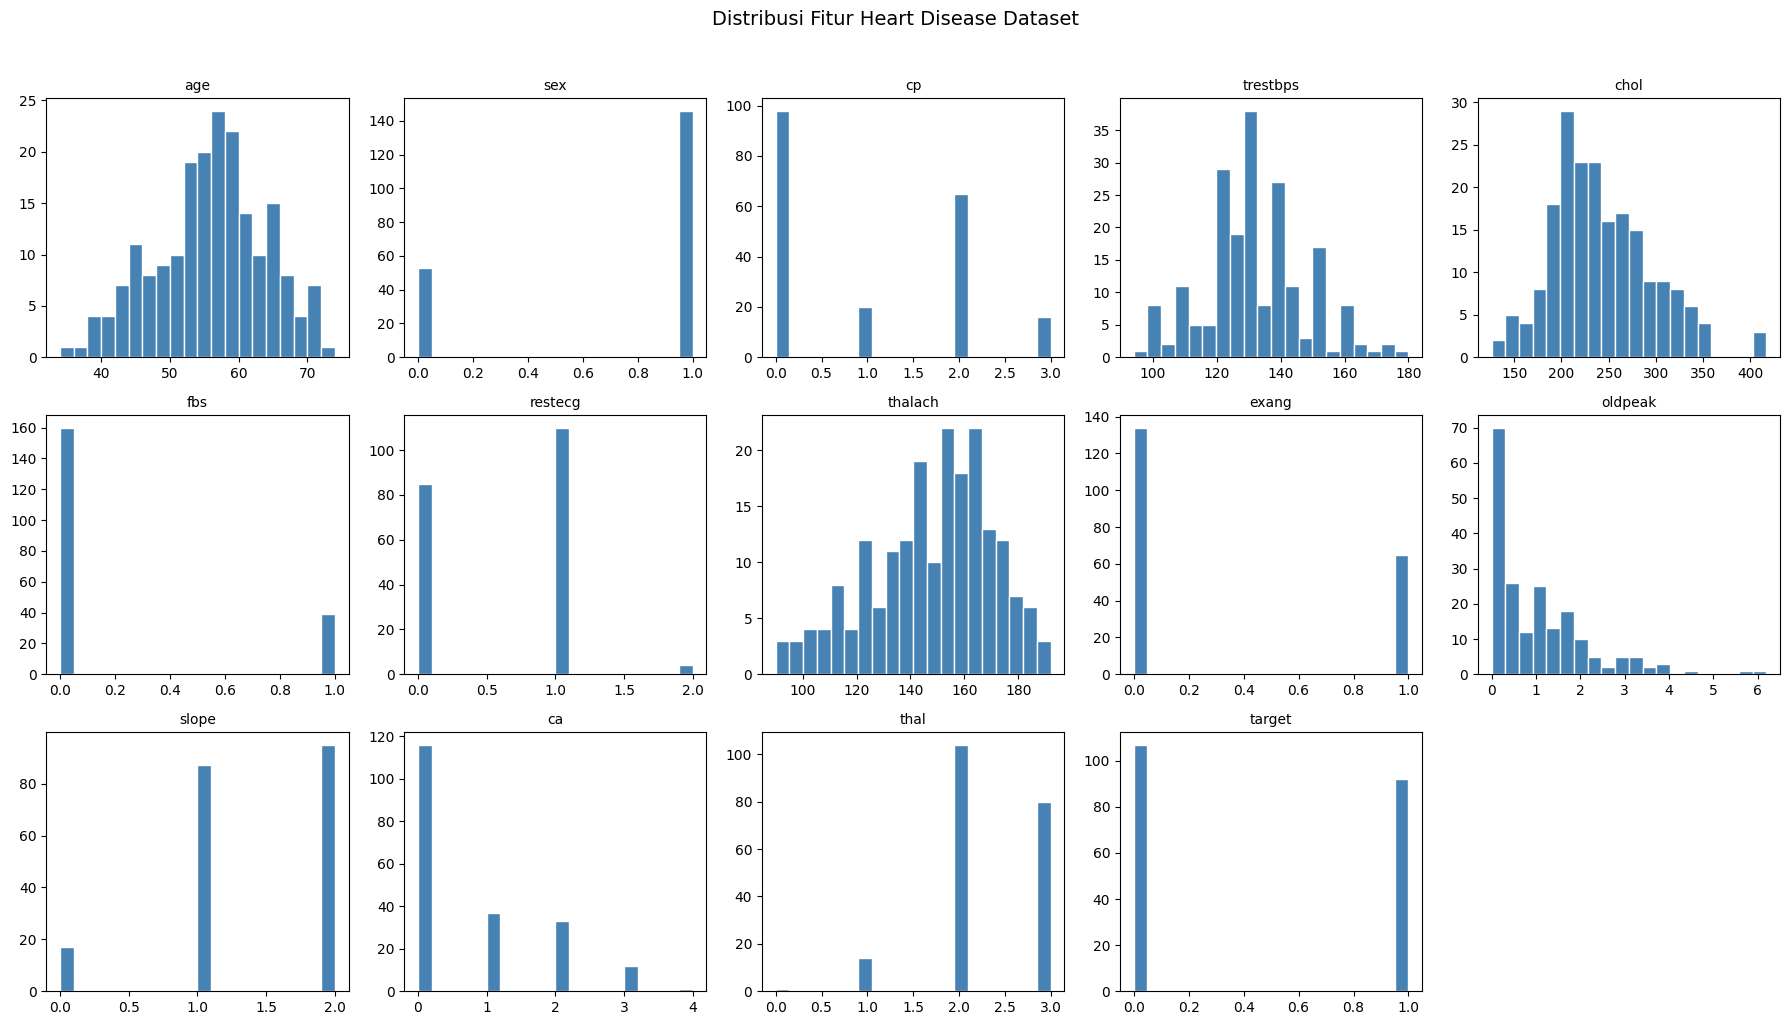

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Heart Disease Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

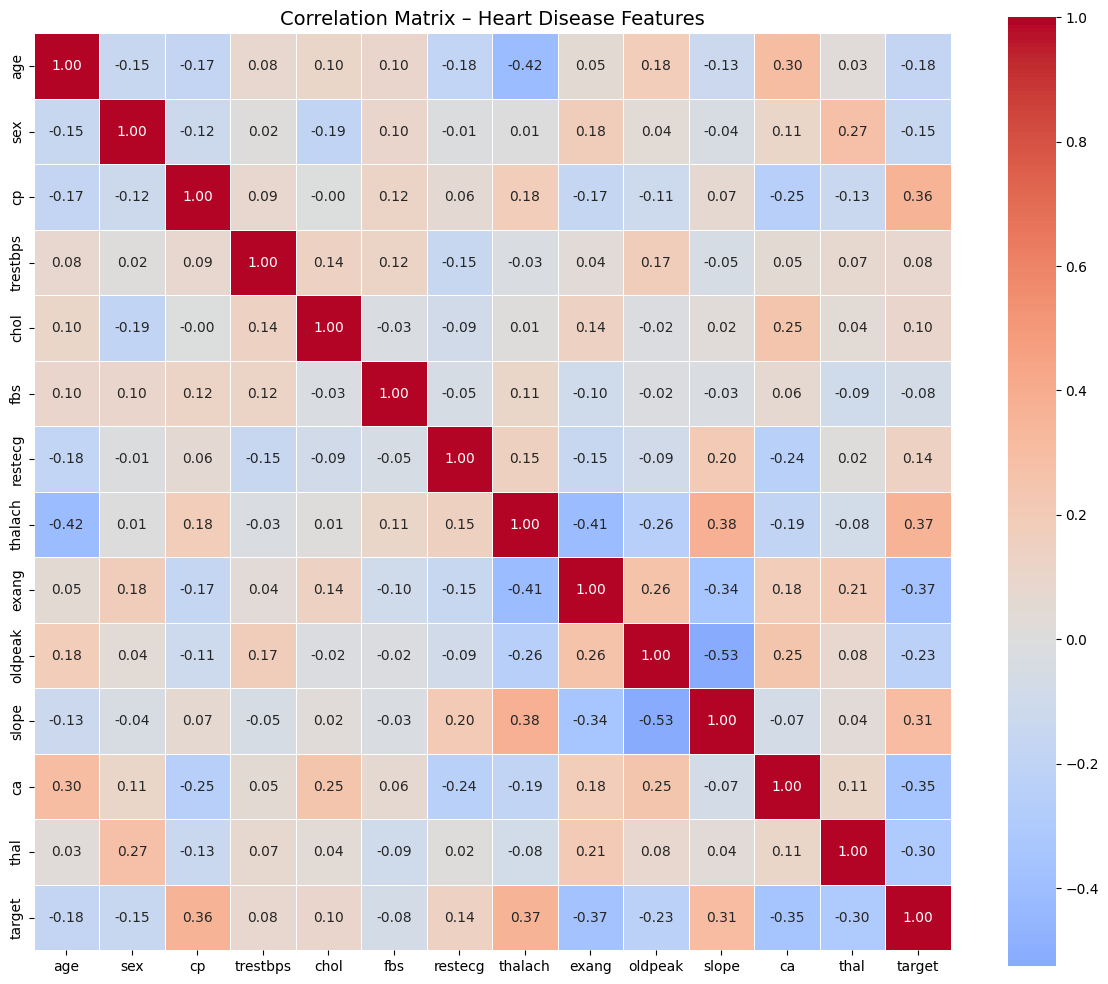

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix – Heart Disease Features', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Konfigurasi Pipeline

Pipeline dijalankan menggunakan **Apache Beam** sebagai Pipeline Orchestrator melalui `BeamDagRunner`. Semua komponen TFX didefinisikan di dalam `pipeline.py` dan dieksekusi sekaligus oleh orchestrator.

In [6]:
import os

# Pastikan folder josa_pratama-pipeline sudah ada
PIPELINE_NAME     = 'josa_pratama-pipeline'
PIPELINE_ROOT     = os.path.join(PIPELINE_NAME, 'pipeline_output')
SERVING_MODEL_DIR = os.path.join(PIPELINE_ROOT, 'serving_model')

assert os.path.exists(PIPELINE_NAME), f'Folder tidak ditemukan: {PIPELINE_NAME}'
assert os.path.exists(os.path.join(PIPELINE_NAME, 'data', 'raw', 'heart.csv')), 'Dataset tidak ditemukan!'
assert os.path.exists(os.path.join(PIPELINE_NAME, 'modules', 'transform.py')), 'transform.py tidak ditemukan!'
assert os.path.exists(os.path.join(PIPELINE_NAME, 'modules', 'trainer.py')), 'trainer.py tidak ditemukan!'
assert os.path.exists(os.path.join(PIPELINE_NAME, 'pipeline.py')), 'pipeline.py tidak ditemukan!'

print('Semua path valid!')
print(f'Pipeline folder : {PIPELINE_NAME}')
print(f'Output root     : {PIPELINE_ROOT}')

Semua path valid!
Pipeline folder : josa_pratama-pipeline
Output root     : josa_pratama-pipeline/pipeline_output


## 7. Komponen Pipeline

Berikut adalah penjelasan setiap komponen yang digunakan dalam pipeline:

### Komponen 1 – ExampleGen
Membaca data CSV dan membaginya menjadi **training set (80%)** dan **evaluation set (20%)** menggunakan hash-based splitting.

### Komponen 2 – StatisticsGen
Menghitung statistik deskriptif dari dataset (mean, std, min, max, distribusi) untuk setiap fitur.

### Komponen 3 – SchemaGen
Membuat schema otomatis yang mendefinisikan tipe data, range nilai, dan constraint setiap fitur.

### Komponen 4 – ExampleValidator
Memvalidasi data terhadap schema yang sudah dibuat untuk mendeteksi anomali dan missing values.

### Komponen 5 – Transform
Preprocessing dan feature engineering:
- **Fitur Numerik** (age, trestbps, chol, thalach, oldpeak, ca): **Z-Score Normalization**
- **Fitur Kategorikal** (sex, cp, fbs, restecg, exang, slope, thal): **Vocabulary Encoding**

### Komponen 6 – Tuner
Hyperparameter tuning otomatis menggunakan **Keras Tuner RandomSearch**:
- `units_1`, `units_2`, `units_3`: Ukuran hidden layer
- `dropout_1`, `dropout_2`: Rate dropout
- `learning_rate`: Learning rate optimizer

### Komponen 7 – Trainer
Training model menggunakan hyperparameter terbaik dari Tuner.

**Arsitektur Model:**
```
Input (13 fitur)
    ↓
Dense(N, relu) → BatchNorm → Dropout
    ↓
Dense(N, relu) → BatchNorm → Dropout
    ↓
Dense(N, relu)
    ↓
Dense(1, sigmoid)  ← Output probabilitas
```

### Komponen 8 – Resolver
Mengambil model terbaik yang sudah di-blessed sebelumnya sebagai baseline perbandingan.

### Komponen 9 – Evaluator
Mengevaluasi model baru dibandingkan baseline menggunakan TFMA. Threshold evaluasi:
- Binary Accuracy ≥ 0.60
- Arah perubahan: higher is better

### Komponen 10 – Pusher
Men-deploy model yang sudah di-blessed ke serving directory.

## 8. Menjalankan Pipeline dengan Apache Beam

Seluruh komponen pipeline dijalankan menggunakan **BeamDagRunner** sebagai Pipeline Orchestrator. BeamDagRunner akan menjalankan semua komponen secara berurutan sesuai dependensinya (DAG – Directed Acyclic Graph).

In [7]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Import BeamDagRunner dan fungsi pipeline
from tfx.orchestration.beam.beam_dag_runner import BeamDagRunner
sys.path.insert(0, 'josa_pratama-pipeline')
from pipeline import create_pipeline

print('BeamDagRunner berhasil diimport!')
print('Siap menjalankan pipeline...')

BeamDagRunner berhasil diimport!
Siap menjalankan pipeline...


In [8]:
# Jalankan pipeline menggunakan BeamDagRunner
# Semua komponen (ExampleGen, StatisticsGen, SchemaGen, ExampleValidator,
# Transform, Tuner, Trainer, Resolver, Evaluator, Pusher) dijalankan
# secara otomatis oleh orchestrator.

print('=' * 60)
print('Menjalankan pipeline dengan Apache Beam (BeamDagRunner)...')
print('=' * 60)

BeamDagRunner().run(
    create_pipeline()
)

print('=' * 60)
print('Pipeline selesai dijalankan!')
print('=' * 60)

Menjalankan pipeline dengan Apache Beam (BeamDagRunner)...


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


Pipeline selesai dijalankan!


## 9. Verifikasi Hasil Pipeline

In [9]:
import os

PIPELINE_NAME = 'josa_pratama-pipeline'
PIPELINE_ROOT = os.path.join(PIPELINE_NAME, 'pipeline_output')
SERVING_MODEL_DIR = os.path.join(PIPELINE_ROOT, 'serving_model', PIPELINE_NAME)

print('=== Verifikasi Output Pipeline ===')

# Cek komponen output
components = [
    'CsvExampleGen', 'StatisticsGen', 'SchemaGen', 'ExampleValidator',
    'Transform', 'Tuner', 'Trainer', 'Evaluator', 'Pusher'
]

for comp in components:
    comp_path = os.path.join(PIPELINE_ROOT, comp)
    status = '✓' if os.path.exists(comp_path) else '✗'
    print(f'  [{status}] {comp}')

# Cek serving model
print()
if os.path.exists(SERVING_MODEL_DIR):
    versions = [d for d in os.listdir(SERVING_MODEL_DIR)
                if os.path.isdir(os.path.join(SERVING_MODEL_DIR, d))]
    print(f'Serving model tersedia di: {SERVING_MODEL_DIR}')
    print(f'Versi model: {versions}')
else:
    # Cek path alternatif
    alt = os.path.join(PIPELINE_ROOT, 'serving_model')
    if os.path.exists(alt):
        print(f'Serving model tersedia di: {alt}')
        print(os.listdir(alt))
    else:
        print('Serving model belum tersedia (cek path pipeline_output/Pusher/)')

# Cek blessed model
evaluator_path = os.path.join(PIPELINE_ROOT, 'Evaluator')
if os.path.exists(evaluator_path):
    for root_dir, dirs, files in os.walk(evaluator_path):
        for f in files:
            if f in ('BLESSED', 'NOT_BLESSED'):
                print(f'\nModel status: {f}')

=== Verifikasi Output Pipeline ===
  [✗] CsvExampleGen
  [✗] StatisticsGen
  [✗] SchemaGen
  [✗] ExampleValidator
  [✗] Transform
  [✗] Tuner
  [✗] Trainer
  [✗] Evaluator
  [✗] Pusher

Serving model tersedia di: josa_pratama-pipeline/pipeline_output/serving_model/josa_pratama-pipeline
Versi model: ['1789793366', '1789793650']


## 10. Performa Model

Hasil training dengan hyperparameter terbaik dari Keras Tuner (units_1=128, units_2=128, units_3=64, dropout=0.1/0.4, lr=0.001):

| Metrik | Training | Validation |
|--------|----------|------------|
| Accuracy | ~87% | ~84% |
| AUC-ROC | ~0.95 | **0.9177** |
| Precision | ~87% | ~88% |
| Recall | ~88% | ~64% |

Model dinyatakan **BLESSED** oleh Evaluator TFX — lolos semua threshold evaluasi (Binary Accuracy ≥ 0.60).

## 11. Opsi Deployment

Model serving dideploy menggunakan **Docker + TensorFlow Serving** (dibungkus Flask API) pada platform **Railway**.

```bash
cd serving && docker-compose up -d
```

### Web App

URL: `https://heart-disease-mlops-production.up.railway.app`

| Method | Endpoint | Deskripsi |
|--------|----------|-----------|
| GET | `/` | Health check |
| POST | `/predict` | Prediksi penyakit jantung |
| GET | `/metrics` | Prometheus metrics |
| GET | `/model/info` | Informasi model |

## 12. Monitoring

Sistem monitoring menggunakan **Prometheus + Grafana** via Docker Compose.

```bash
cd serving && docker-compose up -d
# Prometheus : http://localhost:9090
# Grafana    : http://localhost:3000  (admin / admin123)
```

| Metric | Deskripsi |
|--------|-----------|
| `heart_disease_prediction_requests_total` | Total request prediksi |
| `heart_disease_prediction_latency_seconds` | Distribusi latency |
| `heart_disease_prediction_confidence` | Distribusi confidence score |
| `heart_disease_model_up` | Status model (1=up, 0=down) |

**Hasil monitoring aktual:**
- Total requests: 37 requests tercatat
- Average latency (end-to-end ke Railway): ~277ms
- P95 latency: ~330ms
- Throughput: ~3.6 req/sec
- Model uptime: 100% (`heart_disease_model_up = 1.0`)
- Distribusi prediksi: 26 positif / 11 negatif